**Import required libraries**

In [1]:
# Import libraries for data handling, numerical operations, and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Display all columns and limit row display for easier inspection
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

In [2]:
# Load the four selected Beijing air-quality station datasets
# Urban stations: Dongsi, Guanyuan
# Suburban stations: Changping, Huairou
dongsi = pd.read_csv('PRSA_Data_Dongsi_20130301-20170228.csv')
guanyuan = pd.read_csv('PRSA_Data_Guanyuan_20130301-20170228.csv')
changping = pd.read_csv('PRSA_Data_Changping_20130301-20170228.csv')
huairou = pd.read_csv('PRSA_Data_Huairou_20130301-20170228.csv')

# Check the number of rows and columns in each dataset
print("Dongsi shape:", dongsi.shape)
print("Guanyuan shape:", guanyuan.shape)
print("Changping shape:", changping.shape)
print("Huairou shape:", huairou.shape)

# Check whether all datasets have the same column structure
print("Dongsi columns:", dongsi.columns.tolist())
print("Guanyuan columns:", guanyuan.columns.tolist())
print("Changping columns:", changping.columns.tolist())
print("Huairou columns:", huairou.columns.tolist())

# Display the first five rows of the Dongsi dataset
dongsi.head()

Dongsi shape: (35064, 18)
Guanyuan shape: (35064, 18)
Changping shape: (35064, 18)
Huairou shape: (35064, 18)
Dongsi columns: ['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']
Guanyuan columns: ['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']
Changping columns: ['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']
Huairou columns: ['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


In [3]:
# Create a proper datetime column by combining year, month, day, and hour
for df in [dongsi, guanyuan, changping, huairou]:
    df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Check whether the datetime column has been created correctly
dongsi[['year', 'month', 'day', 'hour', 'datetime']].head()

# Check the unique station name in each dataset
print(dongsi['station'].unique())
print(guanyuan['station'].unique())
print(changping['station'].unique())
print(huairou['station'].unique())

# Merge all four selected station datasets into one dataframe
air_data = pd.concat([dongsi, guanyuan, changping, huairou], ignore_index=True)

# Check the size of the combined dataset
print("Combined dataset shape:", air_data.shape)
print(air_data['station'].value_counts())
air_data.head()

['Dongsi']
['Guanyuan']
['Changping']
['Huairou']
Combined dataset shape: (140256, 19)
station
Dongsi       35064
Guanyuan     35064
Changping    35064
Huairou      35064
Name: count, dtype: int64


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi,2013-03-01 00:00:00
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi,2013-03-01 02:00:00
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi,2013-03-01 04:00:00


In [4]:
# Display data types, non-null counts, and overall structure
air_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        140256 non-null  int64         
 1   year      140256 non-null  int64         
 2   month     140256 non-null  int64         
 3   day       140256 non-null  int64         
 4   hour      140256 non-null  int64         
 5   PM2.5     137163 non-null  float64       
 6   PM10      137915 non-null  float64       
 7   SO2       137511 non-null  float64       
 8   NO2       135690 non-null  float64       
 9   CO        132363 non-null  float64       
 10  O3        136664 non-null  float64       
 11  TEMP      140112 non-null  float64       
 12  PRES      140113 non-null  float64       
 13  DEWP      140110 non-null  float64       
 14  RAIN      140110 non-null  float64       
 15  wd        139655 non-null  object        
 16  WSPM      140136 non-null  float64    

In [5]:
# Count missing values in each column
air_data.isnull().sum()

# Display missing values in descending order
missing_values = air_data.isnull().sum().sort_values(ascending=False)
missing_values

# Display percentage of missing values in each column
missing_percent = (air_data.isnull().sum() / len(air_data)) * 100
missing_percent.sort_values(ascending=False)

,0
CO,5.627567
NO2,3.255476
O3,2.561031
PM2.5,2.205253
SO2,1.957136
...,...
year,0.000000
hour,0.000000
day,0.000000
station,0.000000


In [6]:
# Generate summary statistics for numerical columns
air_data.describe()

# Count duplicate rows in the combined dataset
print("Duplicate rows:", air_data.duplicated().sum())

Duplicate rows: 0


In [7]:
# Remove the 'No' column because it is only a serial number and not useful for analysis
air_data = air_data.drop(columns=['No'], errors='ignore')

# Reorder columns to make the dataset more organised
air_data = air_data[['station', 'datetime', 'year', 'month', 'day', 'hour',
                     'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                     'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM']]

# Preview the dataset after cleaning and reordering
air_data.head()

,station,datetime,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
0,Dongsi,2013-03-01 00:00:00,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7
1,Dongsi,2013-03-01 01:00:00,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9
2,Dongsi,2013-03-01 02:00:00,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3
3,Dongsi,2013-03-01 03:00:00,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9
4,Dongsi,2013-03-01 04:00:00,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2


In [8]:
# Check the data types after preprocessing steps
air_data.dtypes

# Identify rows that contain missing values
air_data[air_data.isnull().any(axis=1)].head()

# Fill missing values in numerical columns with the median
numeric_cols = air_data.select_dtypes(include=[np.number]).columns
air_data[numeric_cols] = air_data[numeric_cols].fillna(air_data[numeric_cols].median())

# Fill missing values in categorical columns with the mode
categorical_cols = air_data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    air_data[col] = air_data[col].fillna(air_data[col].mode()[0])

# Verify that missing values have been handled
print(air_data.isnull().sum())

station     0
datetime    0
year        0
month       0
day         0
           ..
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
Length: 18, dtype: int64


In [9]:
# Create a season feature based on month
def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Winter'

air_data['season'] = air_data['month'].apply(get_season)

# Create day-of-week feature from datetime
air_data['day_of_week'] = air_data['datetime'].dt.day_name()

# Create weekend indicator: 1 for weekend, 0 for weekday
air_data['is_weekend'] = air_data['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

# Preview newly created features
air_data[['datetime', 'season', 'day_of_week', 'is_weekend']].head()

,datetime,season,day_of_week,is_weekend
0,2013-03-01 00:00:00,Spring,Friday,0
1,2013-03-01 01:00:00,Spring,Friday,0
2,2013-03-01 02:00:00,Spring,Friday,0
3,2013-03-01 03:00:00,Spring,Friday,0
4,2013-03-01 04:00:00,Spring,Friday,0


In [10]:
# Categorise PM2.5 concentration levels into air-quality groups
def pm25_category(pm25):
    if pm25 <= 35:
        return 'Good'
    elif pm25 <= 75:
        return 'Moderate'
    elif pm25 <= 115:
        return 'Unhealthy for Sensitive Group'
    elif pm25 <= 150:
        return 'Unhealthy'
    elif pm25 <= 250:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

air_data['PM2.5_Category'] = air_data['PM2.5'].apply(pm25_category)

# Check the distribution of PM2.5 categories
print(air_data['PM2.5_Category'].value_counts())

PM2.5_Category
Good                             52881
Moderate                         35195
Unhealthy for Sensitive Group    20944
Very Unhealthy                   14284
Unhealthy                        11401
Hazardous                         5551
Name: count, dtype: int64


In [11]:
# Save the cleaned and processed dataset for further analysis
air_data.to_csv('cleaned_combined_air_quality_4stations.csv', index=False)

# Display the first five rows of the final cleaned dataset
air_data.head()

,station,datetime,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,season,day_of_week,is_weekend,PM2.5_Category
0,Dongsi,2013-03-01 00:00:00,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Spring,Friday,0,Good
1,Dongsi,2013-03-01 01:00:00,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Spring,Friday,0,Good
2,Dongsi,2013-03-01 02:00:00,2013,3,1,2,7.0,7.0,7.0,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Spring,Friday,0,Good
3,Dongsi,2013-03-01 03:00:00,2013,3,1,3,3.0,3.0,5.0,18.0,900.0,45.0,-1.4,1026.2,-25.5,0.0,N,4.9,Spring,Friday,0,Good
4,Dongsi,2013-03-01 04:00:00,2013,3,1,4,3.0,3.0,7.0,39.0,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Spring,Friday,0,Good


**Exploratory Data Analysis**


In [12]:
# 1. Statistical summary for selected numerical variables
selected_num_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                     'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

air_data[selected_num_cols].describe()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000
mean,76.941622,101.025640,15.638904,46.864849,1175.632586,57.367127,13.348006,1009.938866,2.329488,0.064869,1.768480
std,77.581306,89.047274,21.642794,32.452210,1070.999537,55.452888,11.500315,10.474487,13.848800,0.826346,1.252057
min,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,20.000000,35.000000,2.000000,22.000000,500.000000,14.000000,3.000000,1001.500000,-9.200000,0.000000,0.900000
50%,53.000000,79.000000,7.000000,39.000000,900.000000,45.000000,14.300000,1009.500000,2.900000,0.000000,1.400000
75%,106.000000,139.000000,19.000000,64.000000,1400.000000,80.000000,23.100000,1018.100000,15.000000,0.000000,2.200000
max,882.000000,999.000000,315.000000,270.000000,10000.000000,1071.000000,41.400000,1042.000000,29.100000,72.500000,12.900000


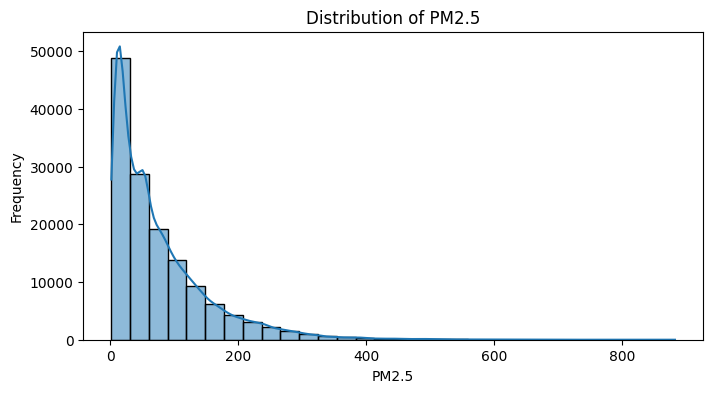

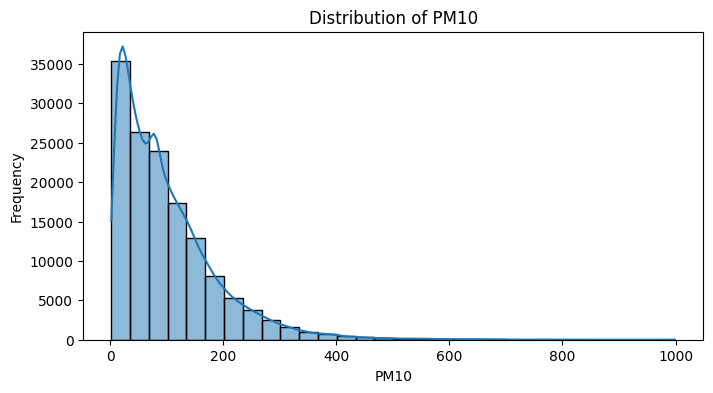

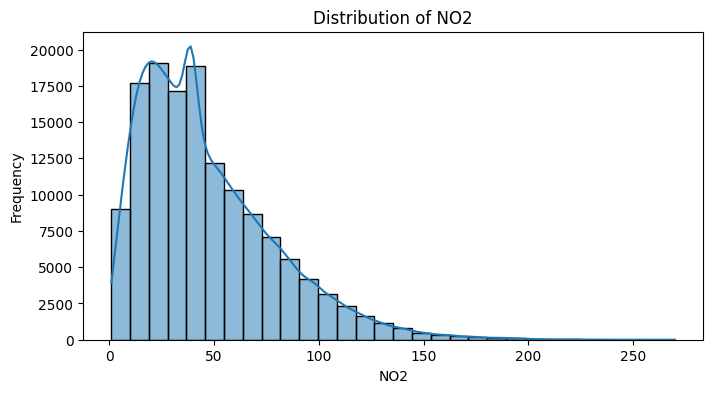

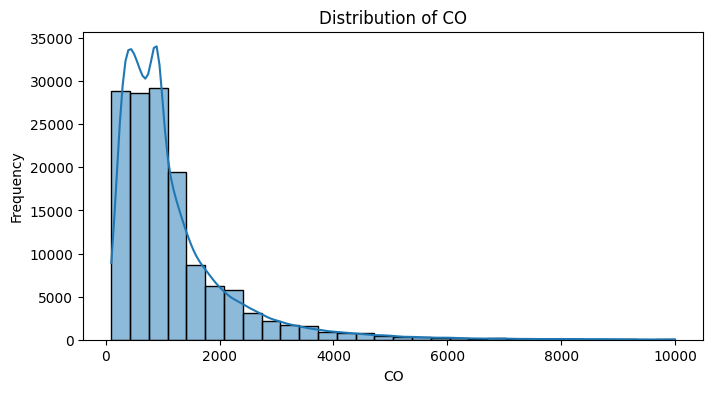

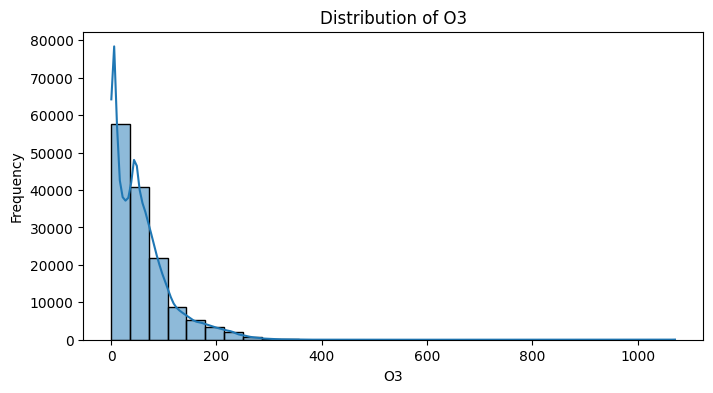

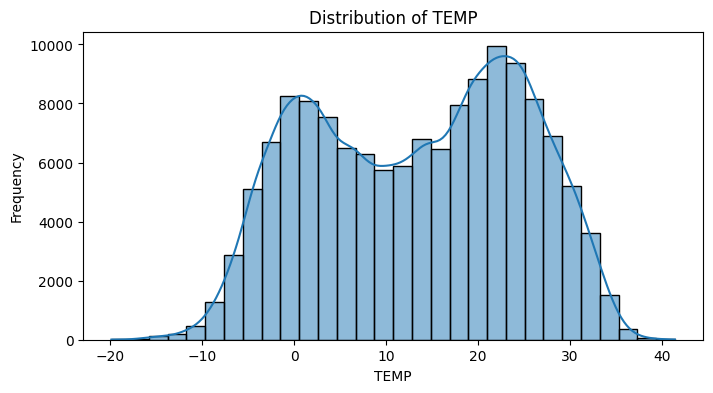

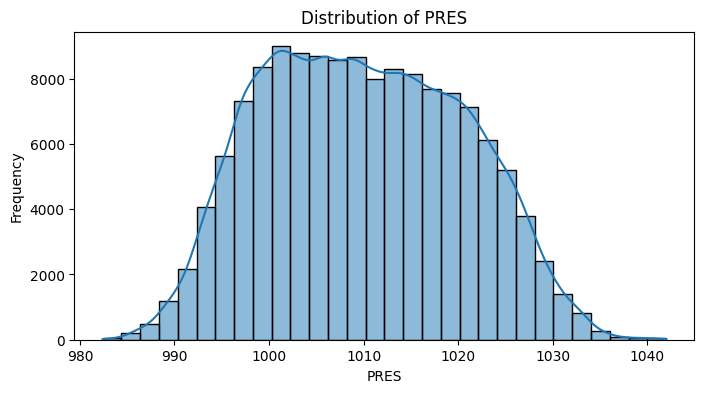

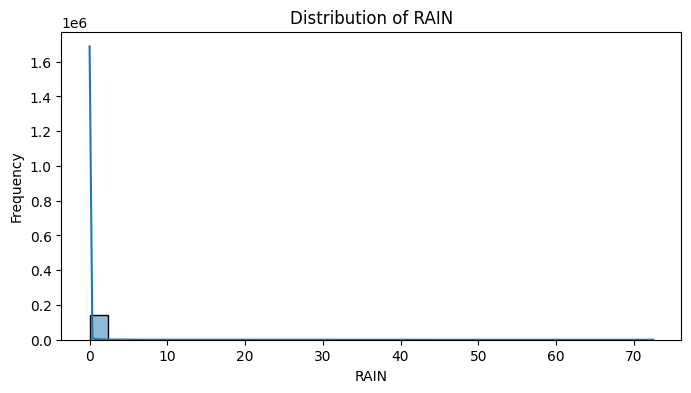

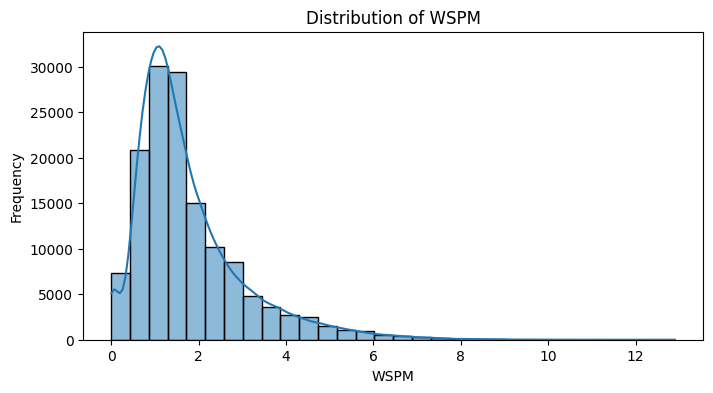

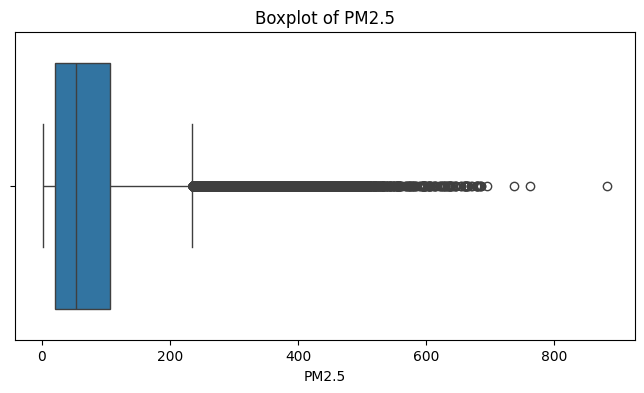

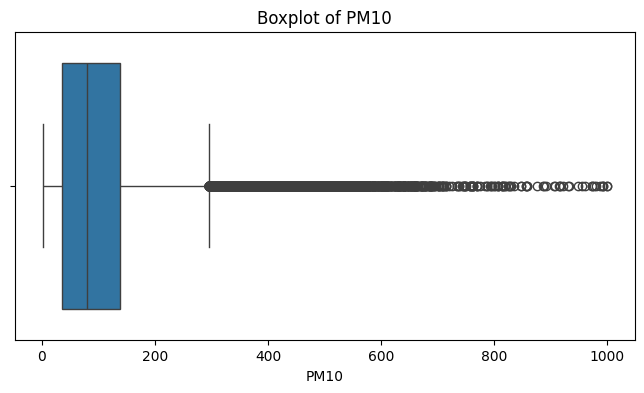

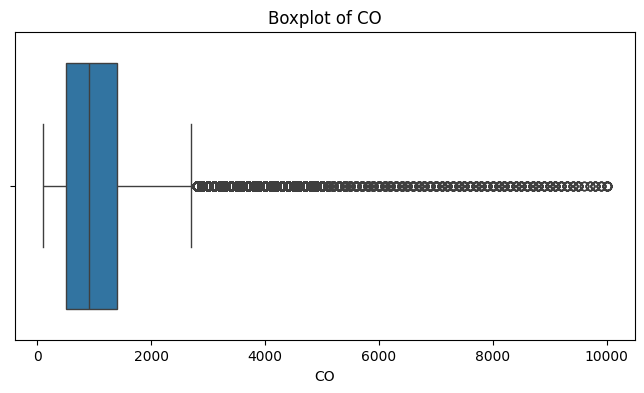

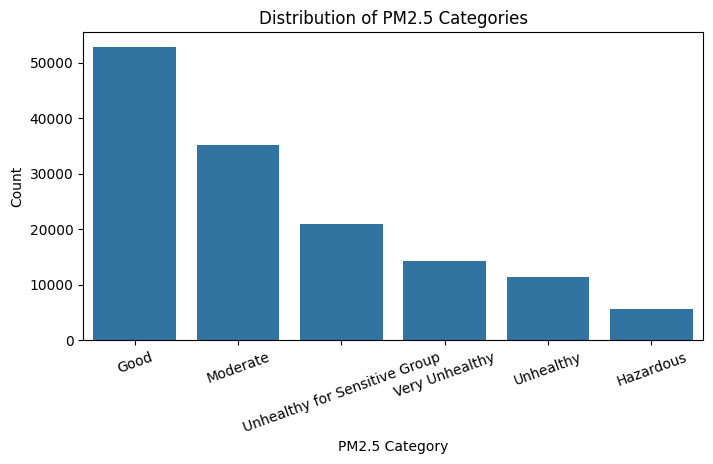

In [13]:
# Univariate analysis
# Select key pollutant variables for univariate analysis
pollutant_vars = ['PM2.5', 'PM10', 'NO2', 'CO', 'O3']

# Plot histograms for selected pollutant variables
for col in pollutant_vars:
    plt.figure(figsize=(8, 4))
    sns.histplot(air_data[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Select key meteorological variables for univariate analysis
weather_vars = ['TEMP', 'PRES', 'RAIN', 'WSPM']

# Plot histograms for selected meteorological variables
for col in weather_vars:
    plt.figure(figsize=(8, 4))
    sns.histplot(air_data[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Use boxplots to examine spread and outliers in major pollutant variables
boxplot_vars = ['PM2.5', 'PM10', 'CO']

for col in boxplot_vars:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=air_data[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

# Show the distribution of PM2.5 air-quality categories
plt.figure(figsize=(8, 4))
sns.countplot(data=air_data, x='PM2.5_Category', order=air_data['PM2.5_Category'].value_counts().index)
plt.title('Distribution of PM2.5 Categories')
plt.xlabel('PM2.5 Category')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.show()

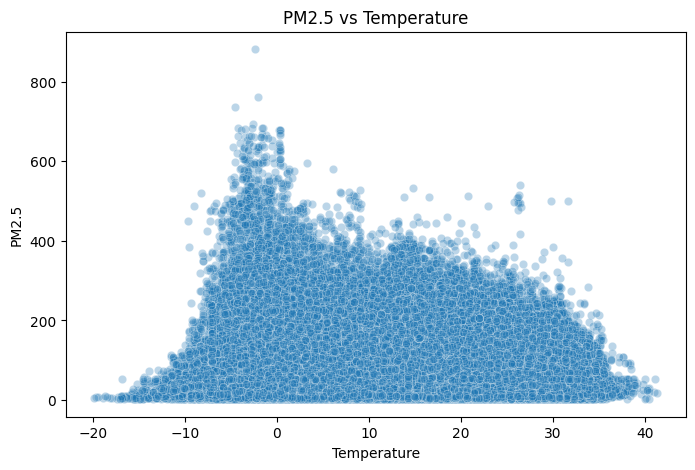

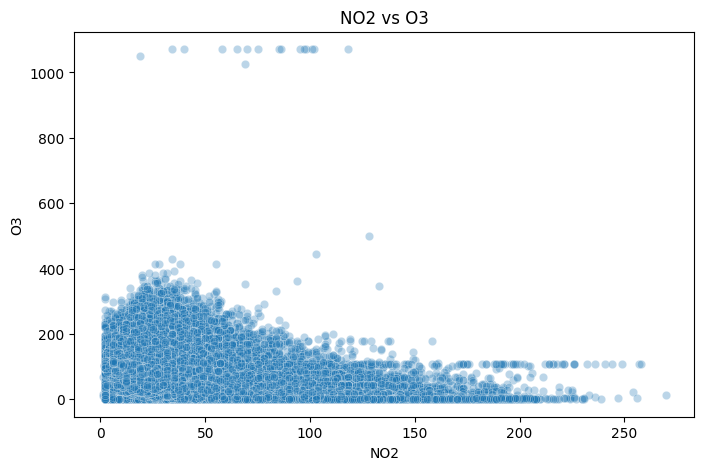

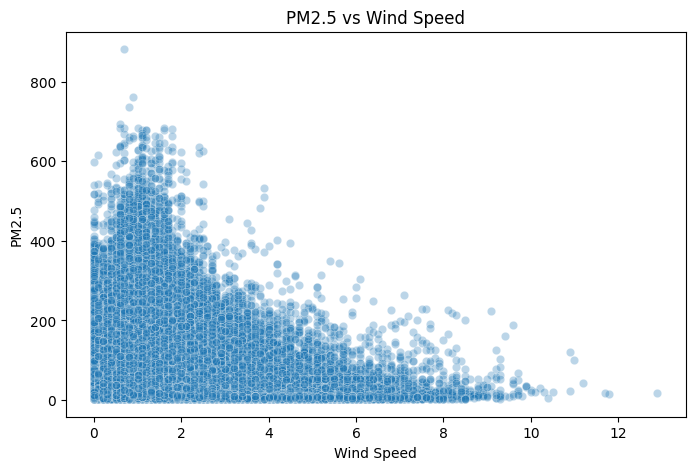

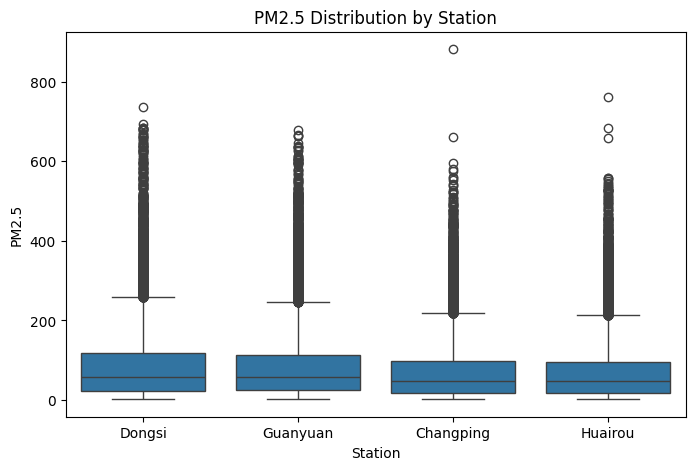

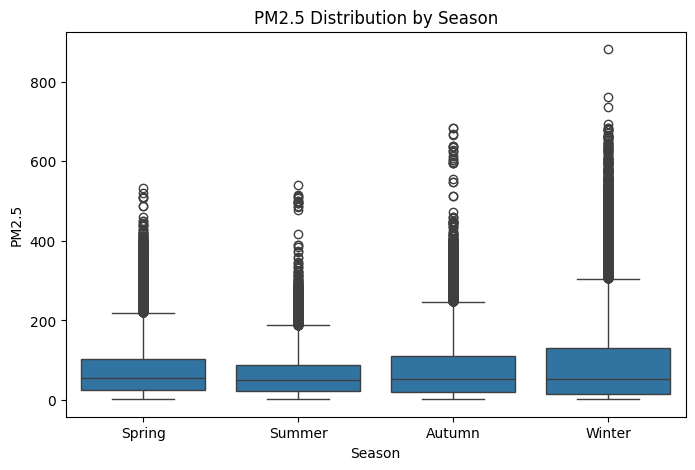

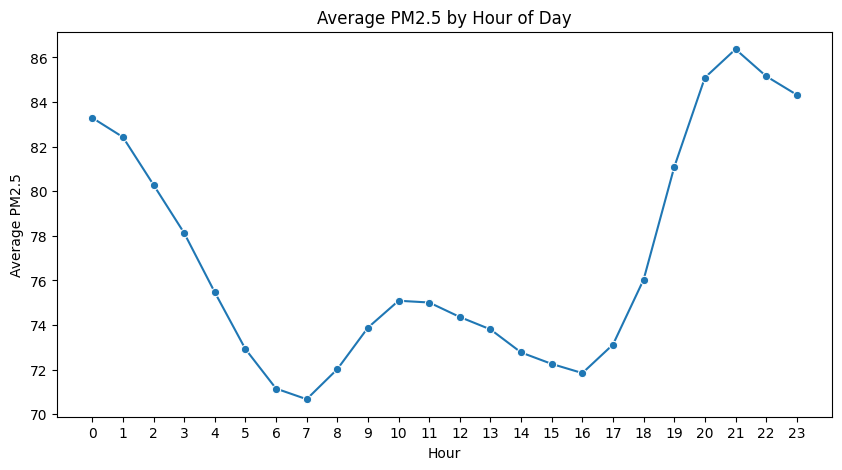

In [14]:
# Bivariate Analysis
# Examine the relationship between PM2.5 concentration and temperature
plt.figure(figsize=(8, 5))
sns.scatterplot(data=air_data, x='TEMP', y='PM2.5', alpha=0.3)
plt.title('PM2.5 vs Temperature')
plt.xlabel('Temperature')
plt.ylabel('PM2.5')
plt.show()

# Examine the relationship between NO2 and O3
plt.figure(figsize=(8, 5))
sns.scatterplot(data=air_data, x='NO2', y='O3', alpha=0.3)
plt.title('NO2 vs O3')
plt.xlabel('NO2')
plt.ylabel('O3')
plt.show()

# Examine the relationship between PM2.5 and wind speed
plt.figure(figsize=(8, 5))
sns.scatterplot(data=air_data, x='WSPM', y='PM2.5', alpha=0.3)
plt.title('PM2.5 vs Wind Speed')
plt.xlabel('Wind Speed')
plt.ylabel('PM2.5')
plt.show()

# Compare PM2.5 concentration across the selected stations
plt.figure(figsize=(8, 5))
sns.boxplot(data=air_data, x='station', y='PM2.5')
plt.title('PM2.5 Distribution by Station')
plt.xlabel('Station')
plt.ylabel('PM2.5')
plt.show()

# Compare PM2.5 concentration across seasons
plt.figure(figsize=(8, 5))
sns.boxplot(data=air_data, x='season', y='PM2.5')
plt.title('PM2.5 Distribution by Season')
plt.xlabel('Season')
plt.ylabel('PM2.5')
plt.show()

# Analyse how average PM2.5 changes across different hours of the day
hourly_pm25 = air_data.groupby('hour')['PM2.5'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_pm25, x='hour', y='PM2.5', marker='o')
plt.title('Average PM2.5 by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average PM2.5')
plt.xticks(range(0, 24))
plt.show()

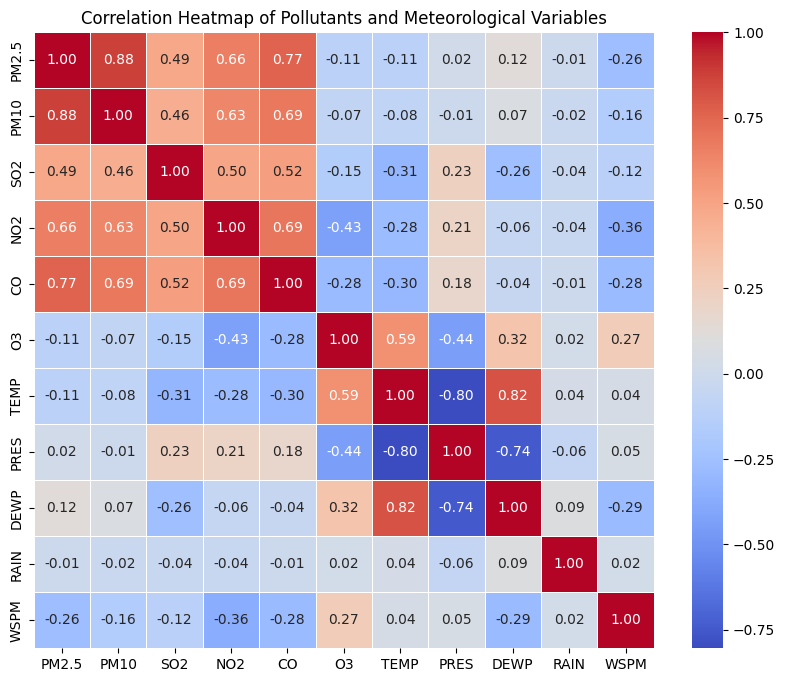

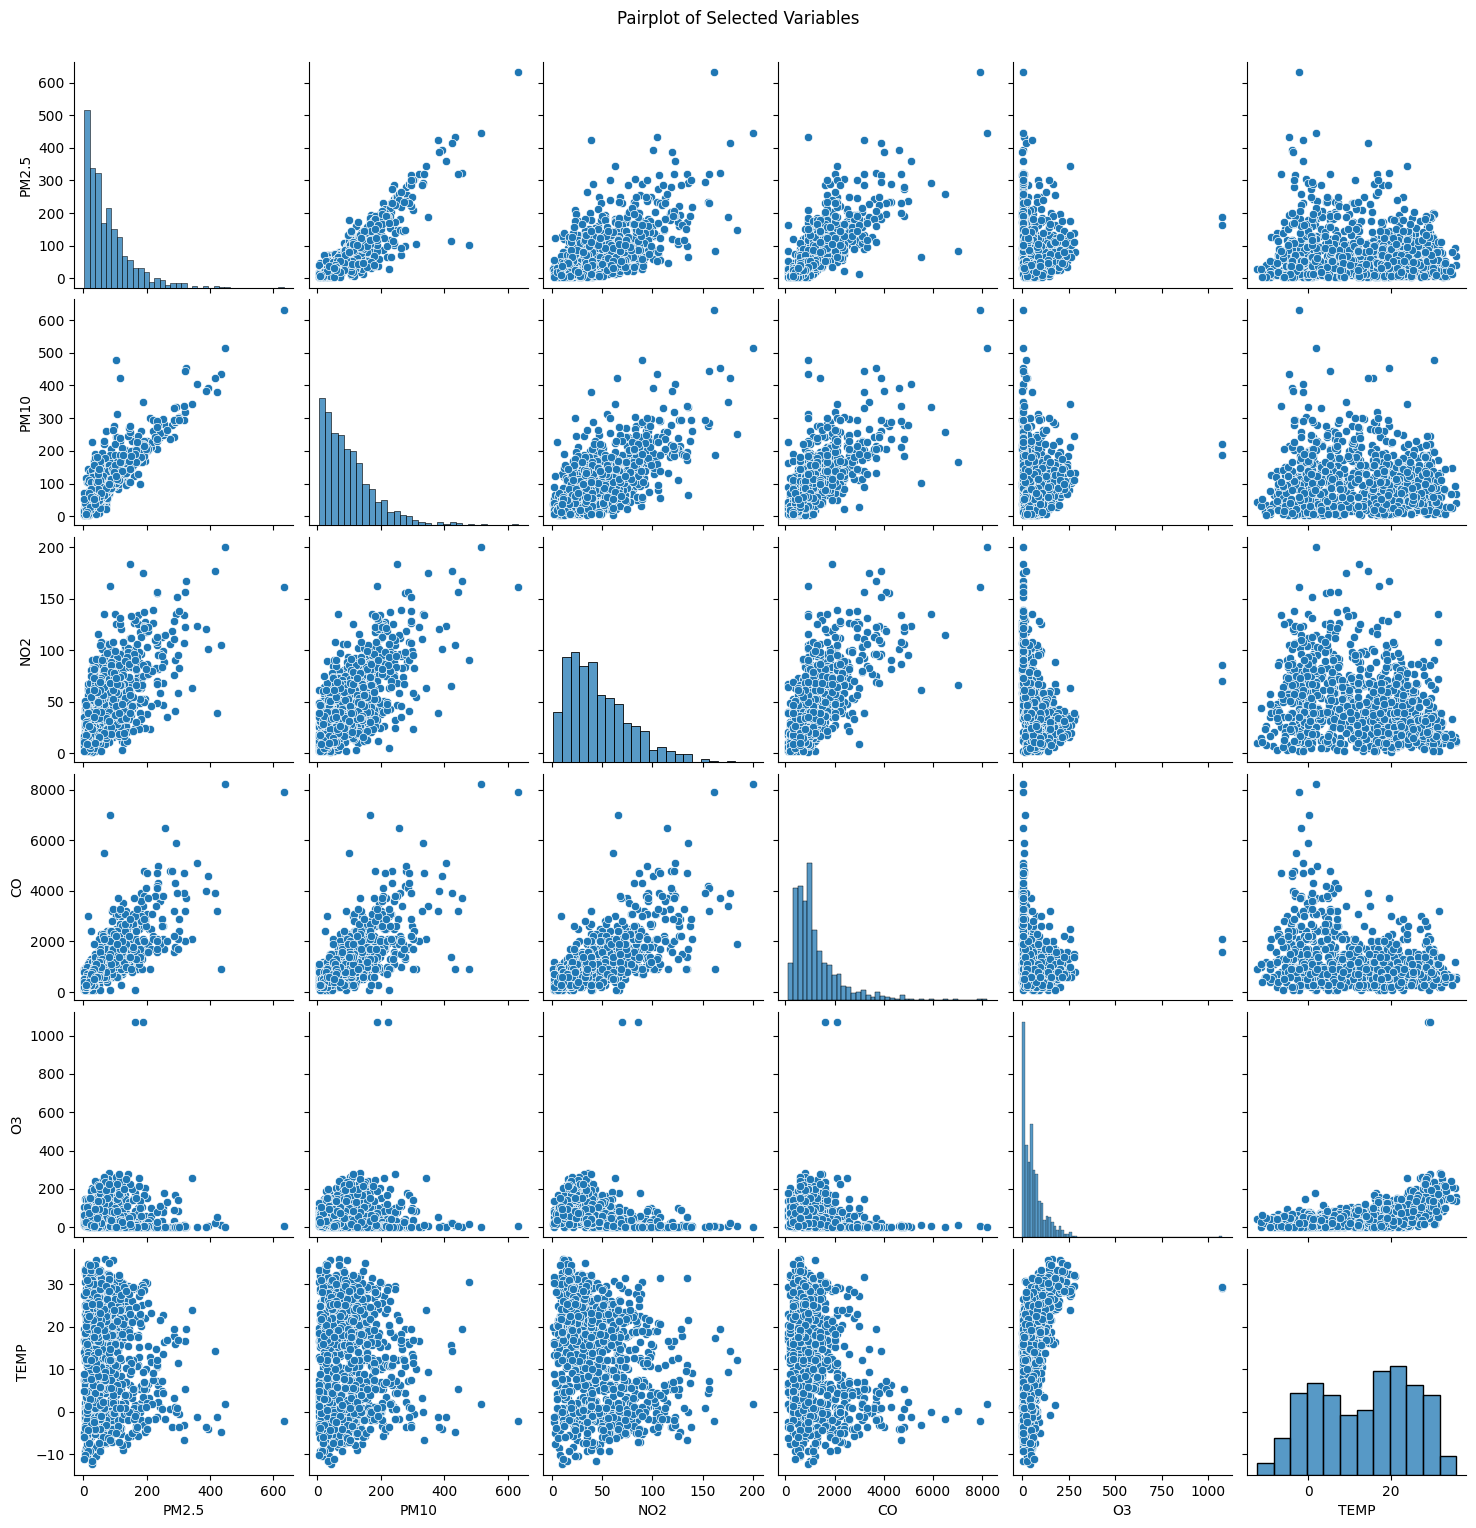

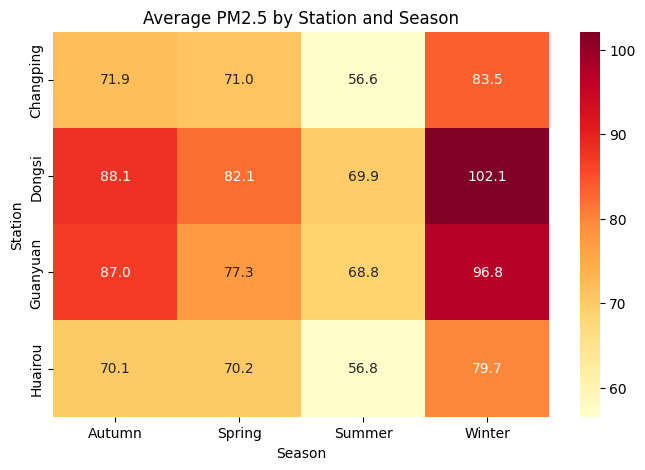

In [15]:
# Multivariate Analysis
# Correlation matrix for pollutants and meteorological variables
corr_matrix = air_data[selected_num_cols].corr()

corr_matrix

# Heatmap to visualise correlations among variables
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Pollutants and Meteorological Variables')
plt.show()

# Pairplot for a smaller set of important variables
pairplot_cols = ['PM2.5', 'PM10', 'NO2', 'CO', 'O3', 'TEMP']

sns.pairplot(air_data[pairplot_cols].sample(1000, random_state=42), diag_kind='hist')
plt.suptitle('Pairplot of Selected Variables', y=1.02)
plt.show()

# Additional multivariate view: average PM2.5 by station and season
station_season_pm25 = air_data.groupby(['station', 'season'])['PM2.5'].mean().unstack()

station_season_pm25

# Heatmap of average PM2.5 by station and season
plt.figure(figsize=(8, 5))
sns.heatmap(station_season_pm25, annot=True, cmap='YlOrRd', fmt='.1f')
plt.title('Average PM2.5 by Station and Season')
plt.xlabel('Season')
plt.ylabel('Station')
plt.show()


**Model Building**

In [16]:
# Define the target variable
y = air_data['PM2.5']

# Define input features
X = air_data.drop(columns=['PM2.5', 'PM2.5_Category'])

In [17]:
# Separate numerical and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['year', 'month', 'day', 'hour', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'is_weekend']
Categorical features: ['station', 'wd', 'season', 'day_of_week']


In [18]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (112204, 20)
Testing set shape: (28052, 20)


In [19]:
# Preprocessing for numerical features:
# - fill missing values with median
# - scale features for models that benefit from standardisation
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features:
# - fill missing values with most frequent value
# - convert categories into numeric form using one-hot encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [20]:
# Create pipelines for different regression models
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

In [21]:
# Train Linear Regression
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Train Random Forest
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Train Gradient Boosting
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

In [22]:
# Create a function to evaluate regression models
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name} Performance")
    print("MAE:", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("R²:", round(r2, 3))
    print("-" * 40)

# Evaluate all baseline models
evaluate_model(y_test, lr_pred, "Linear Regression")
evaluate_model(y_test, rf_pred, "Random Forest Regressor")
evaluate_model(y_test, gb_pred, "Gradient Boosting Regressor")

Linear Regression Performance
MAE: 19.568
RMSE: 30.312
R²: 0.846
----------------------------------------
Random Forest Regressor Performance
MAE: 10.419
RMSE: 18.216
R²: 0.944
----------------------------------------
Gradient Boosting Regressor Performance
MAE: 15.012
RMSE: 24.131
R²: 0.902
----------------------------------------


**Parameter optimisation using GridSearchCV**

In [23]:
# Create a pipeline for Random Forest tuning
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Define the parameter grid
param_grid = {
    'model__n_estimators': [100],
    'model__max_depth': [10, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=2,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

X_train_sample = X_train.sample(20000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

grid_search.fit(X_train_sample, y_train_sample)

Fitting 2 folds for each of 4 candidates, totalling 8 fits


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['year',
                                                                          'month',
                                                                          'day',
                                                                          'hour',
                                                                          'PM10',
                                                                          'SO2',
                                                                          'NO2',
                                                                          'CO',
                                                                          'O3',
                                                                          'TEMP',
                                                                          'PRES',
                                                                          'DEWP',
                                                                          'RAIN',
                                                                          'WSPM',
                                                                          'is_weekend']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['station',
                                                                          'wd',
                                                                          'season',
                                                                          'day_of_week'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [10, None],
                         'model__min_samples_leaf': [1],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100]},
             scoring='r2', verbose=1)

In [24]:
# Display the best parameters and best cross-validation score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation R²:", round(grid_search.best_score_, 3))

Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best cross-validation R²: 0.9


In [25]:
# Use the best model found by GridSearchCV
best_rf_model = grid_search.best_estimator_

# Predict on the test set
best_rf_pred = best_rf_model.predict(X_test)

# Evaluate tuned Random Forest
evaluate_model(y_test, best_rf_pred, "Tuned Random Forest Regressor")

Tuned Random Forest Regressor Performance
MAE: 13.263
RMSE: 22.827
R²: 0.913
----------------------------------------


In [26]:
# Store model results in a summary table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'Tuned Random Forest'],
    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, gb_pred),
        mean_absolute_error(y_test, best_rf_pred)
    ],
    'RMSE': [
        mean_squared_error(y_test, lr_pred) ** 0.5,
        mean_squared_error(y_test, rf_pred) ** 0.5,
        mean_squared_error(y_test, gb_pred) ** 0.5,
        mean_squared_error(y_test, best_rf_pred) ** 0.5
    ],
    'R2': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred),
        r2_score(y_test, best_rf_pred)
    ]
})

results.round(3)

,Model,MAE,RMSE,R2
0,Linear Regression,19.568,30.312,0.846
1,Random Forest,10.419,18.216,0.944
2,Gradient Boosting,15.012,24.131,0.902
3,Tuned Random Forest,13.263,22.827,0.913


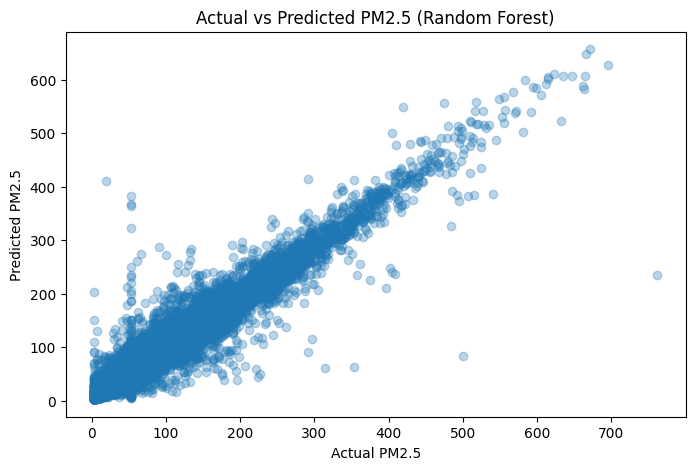

In [30]:
# Plot actual vs predicted PM2.5 values for the best-performing model
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_pred, alpha=0.3)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted PM2.5 (Random Forest)")
plt.show()

In [31]:
# Extract feature names after preprocessing from the Random Forest model
feature_names_num = numeric_features
feature_names_cat = rf_model.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['onehot'] \
    .get_feature_names_out(categorical_features)

all_feature_names = list(feature_names_num) + list(feature_names_cat)

# Extract feature importances from the Random Forest model
importances = rf_model.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

,Feature,Importance
4,PM10,0.796510
7,CO,0.085248
11,DEWP,0.016822
5,SO2,0.012713
9,TEMP,0.012007
6,NO2,0.011216
10,PRES,0.007413
2,day,0.007382
36,season_Spring,0.006795
8,O3,0.006639


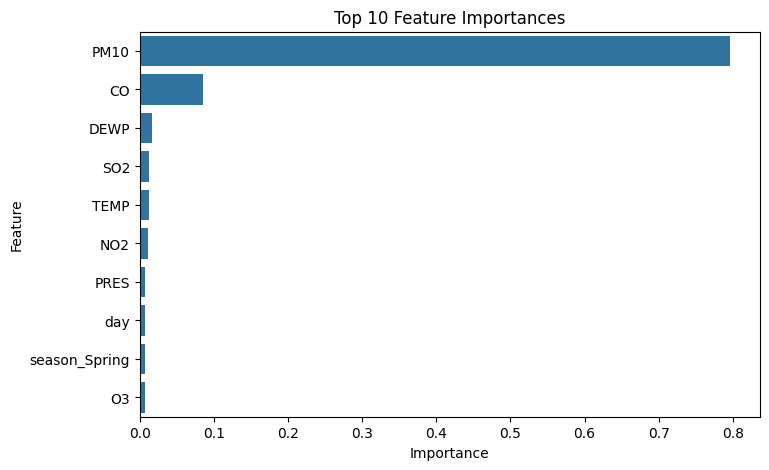

In [32]:
# Plot the top 10 most important features
top_features = feature_importance_df.head(10)

plt.figure(figsize=(8, 5))
sns.barplot(data=top_features, x='Importance', y='Feature')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()